# Inverse Sizing + Active Learning Backtest
**Period:** January 1 – March 25, 2026  
**Starting balance:** $10,000

## Strategy
Identical to the Active Learning backtest, with one change: **bet size is an inverse function of the model–Kalshi edge**.

The intuition: a small gap between model and Kalshi suggests a subtle, reliable inefficiency — bet more. A large gap may indicate model error or stale data — bet less.

$$\text{bet} = \text{clip}\!\left(\frac{\text{MAX\_BET} \times \text{REF\_EDGE}_{pp}}{|\text{edge}|_{pp}},\ \text{MIN\_BET},\ \text{MAX\_BET}\right)$$

| Edge (pp) | Bet size |
|-----------|----------|
| ≤ 5 pp    | $20 (max) |
| 10 pp     | $10       |
| 20 pp     | $5        |
| 50 pp     | $2        |
| ≥ 100 pp  | $1 (min)  |

| Parameter | Value |
|-----------|-------|
| Max bet | $20 |
| Min bet | $1 |
| Reference edge (full bet) | 5 pp |
| Strategy selection | Active learning (30-trade exploration, 10-trade re-eval) |
| Max trades/day | 10 (highest \|edge\| markets only) |

In [1]:
import os, re, json, time, base64, datetime, math, random
from pathlib import Path
from collections import defaultdict

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

from cryptography.hazmat.primitives import serialization, hashes
from cryptography.hazmat.primitives.asymmetric import padding
from cryptography.hazmat.backends import default_backend

%matplotlib inline
plt.rcParams.update({'figure.dpi': 130, 'font.size': 10})

/Users/benjaminthompson/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
# ── Configuration ─────────────────────────────────────────────────────────────
KALSHI_KEY_ID   = os.environ.get('KALSHI_KEY_ID', '')
KALSHI_KEY_FILE = os.environ.get('KALSHI_KEY_FILE', '')
KALSHI_BASE     = 'https://api.elections.kalshi.com'

BACKTEST_START        = datetime.date(2026, 1, 1)
BACKTEST_END          = datetime.date(2026, 3, 25)
STARTING_BALANCE      = 10_000.00
MAX_TRADES_PER_DAY    = 10       # top-10 by |edge| each day
INITIAL_RANDOM_TRADES = 30
REEVAL_INTERVAL       = 10
RANDOM_SEED           = 42
random.seed(RANDOM_SEED)

# ── Inverse bet sizing ────────────────────────────────────────────────────────
MAX_BET      = 20.0   # largest bet, placed when |edge| <= REF_EDGE_PP
MIN_BET      =  1.0   # floor
REF_EDGE_PP  =  5.0   # edge (pp) at which MAX_BET is used; bets scale as 1/edge above this

def bet_size(edge_pp: float) -> float:
    """Return bet in dollars. Decreases hyperbolically with edge_pp."""
    raw = MAX_BET * REF_EDGE_PP / edge_pp if edge_pp > 0 else MAX_BET
    return max(MIN_BET, min(MAX_BET, raw))

ESPN_BASE  = 'http://site.api.espn.com/apis/site/v2/sports'
CACHE_DIR  = Path('backtest_cache')
CACHE_DIR.mkdir(exist_ok=True)

SPORTS_SERIES = {
    'KXNBAGAME': ('basketball', 'nba'),
    'KXNHLGAME': ('hockey',     'nhl'),
    # WTA/ATP excluded: ESPN tennis rankings are not available historically
    # (only current rankings can be fetched), which would introduce look-ahead bias.
}

# ── Auth ──────────────────────────────────────────────────────────────────────
if not KALSHI_KEY_FILE:
    raise RuntimeError('Set KALSHI_KEY_FILE environment variable')
with open(KALSHI_KEY_FILE, 'rb') as _f:
    _PK = serialization.load_pem_private_key(_f.read(), password=None, backend=default_backend())

def _auth_headers(method, path):
    ts  = str(int(time.time() * 1000))
    msg = ts + method.upper() + path.split('?')[0]
    sig = _PK.sign(msg.encode(),
                   padding.PSS(mgf=padding.MGF1(hashes.SHA256()),
                               salt_length=padding.PSS.DIGEST_LENGTH),
                   hashes.SHA256())
    return {'KALSHI-ACCESS-KEY': KALSHI_KEY_ID,
            'KALSHI-ACCESS-SIGNATURE': base64.b64encode(sig).decode(),
            'KALSHI-ACCESS-TIMESTAMP': ts}

def kalshi_get(path, params=None):
    r = requests.get(KALSHI_BASE + path,
                     headers=_auth_headers('GET', path),
                     params=params, timeout=20)
    r.raise_for_status()
    return r.json()

# Preview the sizing curve
print('Config ready. Key ID:', KALSHI_KEY_ID[:8], '...')
print(f'Bet sizing: MAX=${MAX_BET}, MIN=${MIN_BET}, REF_EDGE={REF_EDGE_PP}pp')
for ep in [1, 2, 5, 10, 15, 20, 30, 50, 75, 100]:
    print(f'  edge={ep:>3}pp → bet=${bet_size(ep):.2f}')

Config ready. Key ID: daf6c7c1 ...
Bet sizing: MAX=$20.0, MIN=$1.0, REF_EDGE=5.0pp
  edge=  1pp → bet=$20.00
  edge=  2pp → bet=$20.00
  edge=  5pp → bet=$20.00
  edge= 10pp → bet=$10.00
  edge= 15pp → bet=$6.67
  edge= 20pp → bet=$5.00
  edge= 30pp → bet=$3.33
  edge= 50pp → bet=$2.00
  edge= 75pp → bet=$1.33
  edge=100pp → bet=$1.00


## 1. Bet Sizing Curve

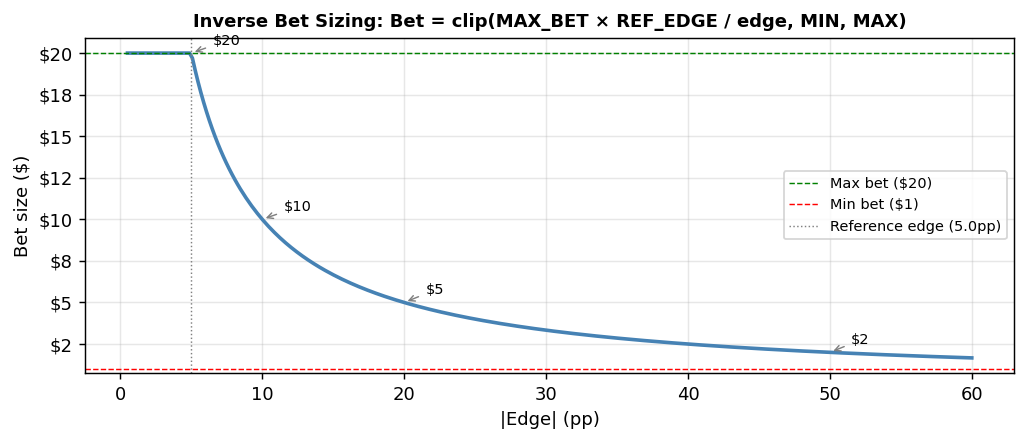

In [3]:
edges = np.linspace(0.5, 60, 300)
bets  = [bet_size(e) for e in edges]

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(edges, bets, color='steelblue', linewidth=2)
ax.axhline(MAX_BET, color='green', linewidth=0.8, linestyle='--', label=f'Max bet (${MAX_BET:.0f})')
ax.axhline(MIN_BET, color='red',   linewidth=0.8, linestyle='--', label=f'Min bet (${MIN_BET:.0f})')
ax.axvline(REF_EDGE_PP, color='grey', linewidth=0.8, linestyle=':',
           label=f'Reference edge ({REF_EDGE_PP}pp)')
for ep in [5, 10, 20, 50]:
    b = bet_size(ep)
    ax.annotate(f'${b:.0f}', xy=(ep, b), xytext=(ep+1.5, b+0.5), fontsize=8,
                arrowprops=dict(arrowstyle='->', color='grey', lw=0.8))
ax.set_xlabel('|Edge| (pp)')
ax.set_ylabel('Bet size ($)')
ax.set_title('Inverse Bet Sizing: Bet = clip(MAX_BET × REF_EDGE / edge, MIN, MAX)',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}'))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('inverse_sizing_curve.png', dpi=130, bbox_inches='tight')
plt.show()

## 2. Load Historical Data (from cache)

In [4]:
MONTH_MAP = {'JAN':1,'FEB':2,'MAR':3,'APR':4,'MAY':5,'JUN':6,
             'JUL':7,'AUG':8,'SEP':9,'OCT':10,'NOV':11,'DEC':12}

def parse_ticker_date(series, ticker):
    rest = ticker[len(series)+1:]
    m = re.match(r'^(\d{2})([A-Z]{3})(\d{2})', rest)
    if not m: return None
    try: return datetime.date(2000+int(m.group(1)), MONTH_MAP[m.group(2)], int(m.group(3)))
    except: return None

def load_settled_markets(series):
    cache_file = CACHE_DIR / f'kalshi_{series}.json'
    if cache_file.exists():
        with open(cache_file) as f:
            data = json.load(f)
        print(f'  {series}: {len(data)} markets (cache hit)')
        return data
    markets, cursor, page = [], None, 0
    while page < 35:
        params = {'status': 'settled', 'series_ticker': series, 'limit': 200}
        if cursor: params['cursor'] = cursor
        resp  = kalshi_get('/trade-api/v2/markets', params)
        batch = resp.get('markets', [])
        for m in batch:
            d = parse_ticker_date(series, m.get('ticker', ''))
            if d and BACKTEST_START <= d <= BACKTEST_END:
                m['_series'] = series; m['_game_date'] = d.isoformat()
                markets.append(m)
        cursor = resp.get('cursor'); page += 1
        if not cursor: break
        time.sleep(0.1)
    with open(cache_file, 'w') as f:
        json.dump(markets, f)
    print(f'  {series}: {len(markets)} markets fetched')
    return markets

print('Loading settled markets...')
all_markets = []
for series in SPORTS_SERIES:
    all_markets.extend(load_settled_markets(series))
print(f'\nTotal: {len(all_markets)} settled markets')

Loading settled markets...
  KXNBAGAME: 1196 markets (cache hit)
  KXNHLGAME: 1012 markets (cache hit)

Total: 2208 settled markets


In [5]:
# ── ESPN probability model ────────────────────────────────────────────────────
_espn_mem = {}

def _record_win_pct(competitor):
    for rec in competitor.get('records', []):
        if rec.get('type') in ('total', 'ytd'):  # NBA='total', NHL='ytd'
            m = re.match(r'^(\d+)-(\d+)', rec.get('summary', ''))
            if m:
                w, l = int(m.group(1)), int(m.group(2))
                if w+l > 0: return w/(w+l)
    return None

def _ml_to_implied(ml):
    ml = float(ml)
    return 100.0/(ml+100.0) if ml > 0 else abs(ml)/(abs(ml)+100.0)

def _parse_team_game(event, sport, league):
    comps = event.get('competitions', [])
    if not comps: return None
    comp        = comps[0]
    competitors = comp.get('competitors', [])
    if len(competitors) < 2: return None
    home = next((c for c in competitors if c.get('homeAway')=='home'), competitors[0])
    away = next((c for c in competitors if c.get('homeAway')=='away'), competitors[1])
    hn = home.get('team',{}).get('displayName','')
    an = away.get('team',{}).get('displayName','')
    if not hn or not an: return None
    for odds in comp.get('odds', []):
        hml = odds.get('homeTeamOdds',{}).get('moneyLine')
        aml = odds.get('awayTeamOdds',{}).get('moneyLine')
        if hml and aml:
            hi, ai = _ml_to_implied(hml), _ml_to_implied(aml)
            t = hi+ai
            if t > 0:
                return dict(home=hn, away=an, prob_home=hi/t, prob_away=ai/t,
                            sport=sport, league=league, source='espn_odds')
    hp, ap = _record_win_pct(home), _record_win_pct(away)
    if hp is None and ap is None: return None
    hp = hp or 0.5; ap = ap or 0.5
    t  = hp+ap
    ph = min(0.95, max(0.05, (hp/t)+0.04))
    return dict(home=hn, away=an, prob_home=ph, prob_away=1-ph,
                sport=sport, league=league, source='win_pct')

_tennis_ranks = {}
ranks_cache = CACHE_DIR / 'tennis_rankings.json'
if ranks_cache.exists():
    with open(ranks_cache) as f:
        _tennis_ranks = json.load(f)
    print(f'Tennis rankings loaded ({len(_tennis_ranks)} players)')
else:
    for league in ('atp', 'wta'):
        url = f'{ESPN_BASE}/tennis/{league}/rankings'
        try:
            resp = requests.get(url, timeout=10).json()
            for entry in resp.get('rankings',[{}])[0].get('ranks',[]):
                athlete = entry.get('athlete', {})
                name = athlete.get('displayName', '')
                rank = entry.get('current', 9999)
                if name: _tennis_ranks[name.lower()] = rank
        except: pass
    with open(ranks_cache, 'w') as f:
        json.dump(_tennis_ranks, f)
    print(f'Tennis rankings fetched ({len(_tennis_ranks)} players)')

def _get_rank(name):
    return _tennis_ranks.get(name.lower(), 300)

def _parse_tennis_match(event, sport, league):
    for grouping in event.get('groupings', []):
        for comp_event in grouping.get('competitions', []):
            competitors = comp_event.get('competitors', [])
            if len(competitors) < 2: continue
            p1 = competitors[0].get('athlete',{}).get('displayName','')
            p2 = competitors[1].get('athletes',[{}])[0].get('displayName','') \
                 if competitors[1].get('athletes') else competitors[1].get('athlete',{}).get('displayName','')
            if not p1 or not p2: continue
            r1, r2 = _get_rank(p1), _get_rank(p2)
            l1, l2 = math.log(r1+1), math.log(r2+1)
            p_p1 = min(0.95, max(0.05, l2/(l1+l2)))
            yield dict(home=p1, away=p2, prob_home=p_p1, prob_away=1-p_p1,
                       sport=sport, league=league, source='log_rank')

def get_espn_games(sport, league, date_str):
    key = (sport, league, date_str)
    if key in _espn_mem: return _espn_mem[key]
    cache_path = CACHE_DIR / f'espn_{sport}_{league}_{date_str}.json'
    # Cache stores the already-parsed game list (list of dicts with home/away/prob_home)
    if cache_path.exists():
        with open(cache_path) as f:
            cached = json.load(f)
        if isinstance(cached, list):
            _espn_mem[key] = cached
            return cached
        raw = cached if isinstance(cached, dict) else {}
    else:
        if league in ('atp','wta'):
            url = f'{ESPN_BASE}/tennis/{league}/scoreboard'
        else:
            url = f'{ESPN_BASE}/{sport}/{league}/scoreboard'
        try:
            raw = requests.get(url, params={'dates': date_str}, timeout=10).json()
        except:
            raw = {}
        if not isinstance(raw, dict): raw = {}
    games = []
    if league in ('atp','wta'):
        for event in raw.get('events', []):
            games.extend(_parse_tennis_match(event, sport, league))
    else:
        for event in raw.get('events', []):
            g = _parse_team_game(event, sport, league)
            if g: games.append(g)
    with open(cache_path, 'w') as f:
        json.dump(games, f)
    _espn_mem[key] = games
    return games

def _name_score(name, text):
    text_l = text.lower()
    parts  = [p.strip() for p in name.lower().split() if len(p) > 2]
    return sum(1 for p in parts if p in text_l)

def match_market_to_game(market, games):
    series   = market.get('_series', '')
    title    = market.get('title', '')
    subtitle = market.get('subtitle', '')
    text     = f'{title} {subtitle}'.lower()
    league_filter = SPORTS_SERIES.get(series, ('',''))[1]
    for game in games:
        if game['league'] != league_filter: continue
        h_score = _name_score(game['home'], text)
        a_score = _name_score(game['away'], text)
        if h_score == 0 or a_score == 0: continue
        if h_score + a_score < 2: continue
        is_home_market = _name_score(game['home'], title) >= _name_score(game['away'], title)
        prob = game['prob_home'] if is_home_market else game['prob_away']
        return game, prob
    return None, None

print('Model and matching functions ready.')

Tennis rankings loaded (300 players)
Model and matching functions ready.


## 3. Run the Backtest

Both virtual P&L streams (trust and fade) use the **same inverse bet sizing** on every trade, so the comparison at re-evaluation time is apples-to-apples.

In [6]:
def compute_trade_pnl(side, price_yes_ask, price_yes_bid, result, budget):
    """Return (price, contracts, cost, pnl, won) or None if trade is not executable."""
    price     = price_yes_ask if side == 'yes' else (1.0 - price_yes_bid)
    if price < 0.01 or price > 0.99: return None
    contracts = int(budget / price)
    if contracts < 1: return None
    cost = contracts * price
    won  = (side == result)
    pnl  = contracts * (1.0 - price) if won else -cost
    return price, contracts, cost, pnl, won

# ── Active learning state ─────────────────────────────────────────────────────
initial_strategy = random.choice(['trust', 'fade'])
active_strategy  = initial_strategy
print(f'Random seed {RANDOM_SEED}: initial strategy → {active_strategy.upper()} KALSHI')

trust_cumulative  = 0.0
fade_cumulative   = 0.0
active_cumulative = 0.0
switch_log        = []

trades       = []
balance      = STARTING_BALANCE
balance_hist = []
trade_count  = 0

# ── Backtest loop ─────────────────────────────────────────────────────────────
markets_by_date = defaultdict(list)
for m in all_markets:
    markets_by_date[m['_game_date']].append(m)

date = BACKTEST_START
while date <= BACKTEST_END:
    date_str    = date.isoformat()
    date_8      = date.strftime('%Y%m%d')
    day_markets = markets_by_date.get(date_str, [])

    all_day_games = []
    for series, (sport, league) in SPORTS_SERIES.items():
        all_day_games.extend(get_espn_games(sport, league, date_8))

    seen_events = set()
    candidates  = []

    for market in day_markets:
        event_tk = market.get('event_ticker', market['ticker'])
        if event_tk in seen_events: continue

        try:
            prev_ask = float(market.get('previous_yes_ask_dollars', 0) or 0)
            prev_bid = float(market.get('previous_yes_bid_dollars', 0) or 0)
        except (TypeError, ValueError):
            continue
        if prev_ask < 0.01 or prev_ask > 0.99 or prev_bid < 0.01: continue

        kalshi_mid = (prev_ask + prev_bid) / 2.0
        game, model_prob = match_market_to_game(market, all_day_games)
        if game is None or model_prob is None: continue

        result = market.get('result', '').lower()
        if result not in ('yes', 'no'): continue

        abs_edge = abs(kalshi_mid - model_prob)
        seen_events.add(event_tk)
        candidates.append(dict(
            market=market, kalshi_mid=kalshi_mid, model_prob=model_prob,
            prev_ask=prev_ask, prev_bid=prev_bid, result=result,
            abs_edge=abs_edge, game=game
        ))

    # Select top-10 by absolute edge
    candidates.sort(key=lambda x: x['abs_edge'], reverse=True)
    day_candidates = candidates[:MAX_TRADES_PER_DAY]

    for cand in day_candidates:
        market     = cand['market']
        kalshi_mid = cand['kalshi_mid']
        model_prob = cand['model_prob']
        prev_ask   = cand['prev_ask']
        prev_bid   = cand['prev_bid']
        result     = cand['result']
        game       = cand['game']
        edge_pp    = cand['abs_edge'] * 100.0

        # ── Inverse bet sizing ────────────────────────────────────────────────
        budget = bet_size(edge_pp)

        trust_side = 'yes' if kalshi_mid > model_prob else 'no'
        fade_side  = 'yes' if model_prob > kalshi_mid else 'no'

        # Both virtual streams use the same budget (same sizing, same trade)
        trust_result = compute_trade_pnl(trust_side, prev_ask, prev_bid, result, budget)
        fade_result  = compute_trade_pnl(fade_side,  prev_ask, prev_bid, result, budget)
        if trust_result is None or fade_result is None: continue

        t_price, t_contracts, t_cost, t_pnl, t_won = trust_result
        f_price, f_contracts, f_cost, f_pnl, f_won = fade_result

        trust_cumulative += t_pnl
        fade_cumulative  += f_pnl

        if active_strategy == 'trust':
            a_price, a_contracts, a_cost, a_pnl, a_won, a_side = \
                t_price, t_contracts, t_cost, t_pnl, t_won, trust_side
        else:
            a_price, a_contracts, a_cost, a_pnl, a_won, a_side = \
                f_price, f_contracts, f_cost, f_pnl, f_won, fade_side

        active_cumulative += a_pnl
        balance           += a_pnl
        trade_count       += 1

        trades.append(dict(
            date          = date_str,
            league        = game['league'],
            title         = market.get('title', ''),
            active_strat  = active_strategy,
            side          = a_side,
            kalshi_mid    = round(kalshi_mid * 100, 1),
            model_prob    = round(model_prob * 100, 1),
            edge_pp       = round(edge_pp, 1),
            budget        = round(budget, 2),
            contracts     = a_contracts,
            cost          = round(a_cost, 2),
            result        = result,
            won           = a_won,
            pnl           = round(a_pnl, 2),
            trust_pnl     = round(t_pnl, 2),
            fade_pnl      = round(f_pnl, 2),
            trust_cum     = round(trust_cumulative, 2),
            fade_cum      = round(fade_cumulative, 2),
            active_cum    = round(active_cumulative, 2),
            trade_num     = trade_count,
            balance_after = round(balance, 2),
        ))

        # ── Strategy re-evaluation ────────────────────────────────────────────
        is_exploration_boundary = (trade_count == INITIAL_RANDOM_TRADES)
        is_reeval_boundary = (
            trade_count > INITIAL_RANDOM_TRADES and
            (trade_count - INITIAL_RANDOM_TRADES) % REEVAL_INTERVAL == 0
        )
        if is_exploration_boundary or is_reeval_boundary:
            prev_strat      = active_strategy
            active_strategy = 'trust' if trust_cumulative >= fade_cumulative else 'fade'
            phase = 'exploration→exploit' if is_exploration_boundary else 'reeval'
            switch_log.append(dict(
                trade_num  = trade_count,
                date       = date_str,
                phase      = phase,
                prev_strat = prev_strat,
                new_strat  = active_strategy,
                switched   = (prev_strat != active_strategy),
                trust_cum  = round(trust_cumulative, 2),
                fade_cum   = round(fade_cumulative, 2),
            ))

    balance_hist.append({'date': date, 'balance': balance})
    date += datetime.timedelta(days=1)

df     = pd.DataFrame(trades)
bal_df = pd.DataFrame(balance_hist)
bal_df['date'] = pd.to_datetime(bal_df['date'])

print(f'Backtest complete. {trade_count} trades simulated.')
print(f'Initial strategy: {initial_strategy.upper()} KALSHI')
print(f'Strategy evaluations: {len(switch_log)}')

Random seed 42: initial strategy → TRUST KALSHI
Backtest complete. 57 trades simulated.
Initial strategy: TRUST KALSHI
Strategy evaluations: 3


## 4. Strategy Switching Log

In [7]:
print('Strategy evaluation log:')
print('─' * 82)
print(f'{"Trade#":<8} {"Date":<12} {"Phase":<22} {"Trust P&L":>10} {"Fade P&L":>10} {"Decision"}')
print('─' * 82)
for ev in switch_log:
    arrow = '→ SWITCH' if ev['switched'] else '→ KEEP'
    print(f"{ev['trade_num']:<8} {ev['date']:<12} {ev['phase']:<22} "
          f"${ev['trust_cum']:>+9,.2f} ${ev['fade_cum']:>+9,.2f}  "
          f"{arrow} → {ev['new_strat'].upper()}")
print('─' * 82)

Strategy evaluation log:
──────────────────────────────────────────────────────────────────────────────────
Trade#   Date         Phase                   Trust P&L   Fade P&L Decision
──────────────────────────────────────────────────────────────────────────────────
30       2026-02-25   exploration→exploit    $   +21.71 $   -28.48  → KEEP → TRUST
40       2026-02-26   reeval                 $   +31.43 $   -38.92  → KEEP → TRUST
50       2026-03-25   reeval                 $   +33.82 $   -54.31  → KEEP → TRUST
──────────────────────────────────────────────────────────────────────────────────


## 5. Performance Summary

In [8]:
total_pnl     = round(balance - STARTING_BALANCE, 2)
total_return  = round((balance / STARTING_BALANCE - 1) * 100, 2)
n_trades      = len(df)
n_wins        = int(df['won'].sum()) if n_trades else 0
win_rate      = round(n_wins / n_trades * 100, 1) if n_trades else 0
avg_pnl       = round(df['pnl'].mean(), 2) if n_trades else 0
total_wagered = round(df['cost'].sum(), 2) if n_trades else 0
avg_bet       = round(df['budget'].mean(), 2) if n_trades else 0

bal_series = bal_df['balance']
peak       = bal_series.cummax()
drawdown   = (bal_series - peak) / peak * 100
max_dd     = round(drawdown.min(), 2)

bal_df['daily_pnl'] = bal_df['balance'].diff().fillna(0)
std_daily = bal_df['daily_pnl'].std()
sharpe    = round((bal_df['daily_pnl'].mean() / std_daily) * (252**0.5), 2) if std_daily > 0 else 0

trust_trades = int((df['active_strat'] == 'trust').sum()) if n_trades else 0
fade_trades  = int((df['active_strat'] == 'fade').sum())  if n_trades else 0
n_switches   = sum(1 for e in switch_log if e['switched'])

print('═'*62)
print(f'  INVERSE SIZING BACKTEST  ({BACKTEST_START} → {BACKTEST_END})')
print('═'*62)
print(f'  Starting balance      :  ${STARTING_BALANCE:>10,.2f}')
print(f'  Ending balance        :  ${balance:>10,.2f}')
print(f'  Total P&L             :  ${total_pnl:>+10,.2f}')
print(f'  Total return          :  {total_return:>+9.2f}%')
print('─'*62)
print(f'  Total trades          :  {n_trades:>10}')
print(f'  Wins / Losses         :  {n_wins} / {n_trades - n_wins}')
print(f'  Win rate              :  {win_rate:>9.1f}%')
print(f'  Avg P&L per trade     :  ${avg_pnl:>+9.2f}')
print(f'  Avg bet per trade     :  ${avg_bet:>9.2f}')
print(f'  Total wagered         :  ${total_wagered:>10,.2f}')
print('─'*62)
print(f'  Max drawdown          :  {max_dd:>9.2f}%')
print(f'  Sharpe ratio (ann)    :  {sharpe:>9.2f}')
print('─'*62)
print(f'  Initial strategy      :  {initial_strategy.upper()} KALSHI (random)')
print(f'  Trades on Trust       :  {trust_trades}')
print(f'  Trades on Fade        :  {fade_trades}')
print(f'  Strategy switches     :  {n_switches} of {len(switch_log)} evaluations')
print('─'*62)
print(f'  (virtual) Trust P&L   :  ${trust_cumulative:>+9.2f}')
print(f'  (virtual) Fade P&L    :  ${fade_cumulative:>+9.2f}')
print('═'*62)

ORIGINAL_FADE = dict(
    n_trades=24, wins=4, win_rate=16.7,
    total_pnl=-94.59, total_return=-0.95, total_wagered=237.59,
    avg_pnl=-3.94, max_dd=-0.95, sharpe=-2.26
)
ORIGINAL_TRUST = dict(
    n_trades=55, wins=37, win_rate=67.3,
    total_pnl=-25.77, total_return=-0.26, total_wagered=527.77,
    avg_pnl=-0.47, max_dd=-0.43, sharpe=-1.43
)
ACTIVE_LEARN = dict(
    n_trades=57, wins=41, win_rate=71.9,
    total_pnl=17.12, total_return=0.17, total_wagered=545.88,
    avg_pnl=0.30, max_dd=-0.27, sharpe=0.75
)
THIS = dict(
    n_trades=n_trades, wins=n_wins, win_rate=win_rate,
    total_pnl=total_pnl, total_return=total_return, total_wagered=total_wagered,
    avg_pnl=avg_pnl, max_dd=max_dd, sharpe=sharpe
)
comp = pd.DataFrame({
    'Fade Kalshi\n(10pp, 4/day)':   ORIGINAL_FADE,
    'Trust Kalshi\n(5pp, 20/day)':  ORIGINAL_TRUST,
    'Active Learning\n(top-10/day)': ACTIVE_LEARN,
    'Inverse Sizing\n(this)':        THIS,
})
comp.index = ['Trades','Wins','Win Rate %','Total P&L $','Return %',
              'Wagered $','Avg P&L/trade $','Max DD %','Sharpe']
print('\nAll-strategy comparison:')
display(comp)

══════════════════════════════════════════════════════════════
  INVERSE SIZING BACKTEST  (2026-01-01 → 2026-03-25)
══════════════════════════════════════════════════════════════
  Starting balance      :  $ 10,000.00
  Ending balance        :  $ 10,016.16
  Total P&L             :  $    +16.16
  Total return          :      +0.16%
──────────────────────────────────────────────────────────────
  Total trades          :          57
  Wins / Losses         :  41 / 16
  Win rate              :       71.9%
  Avg P&L per trade     :  $    +0.28
  Avg bet per trade     :  $     7.24
  Total wagered         :  $    392.84
──────────────────────────────────────────────────────────────
  Max drawdown          :      -0.21%
  Sharpe ratio (ann)    :       0.85
──────────────────────────────────────────────────────────────
  Initial strategy      :  TRUST KALSHI (random)
  Trades on Trust       :  57
  Trades on Fade        :  0
  Strategy switches     :  0 of 3 evaluations
──────────────────────

,"Fade Kalshi\n(10pp, 4/day)","Trust Kalshi\n(5pp, 20/day)",Active Learning\n(top-10/day),Inverse Sizing\n(this)
Trades,24.00,55.00,57.00,57.00
Wins,4.00,37.00,41.00,41.00
Win Rate %,16.70,67.30,71.90,71.90
Total P&L $,-94.59,-25.77,17.12,16.16
Return %,-0.95,-0.26,0.17,0.16
Wagered $,237.59,527.77,545.88,392.84
Avg P&L/trade $,-3.94,-0.47,0.30,0.28
Max DD %,-0.95,-0.43,-0.27,-0.21
Sharpe,-2.26,-1.43,0.75,0.85


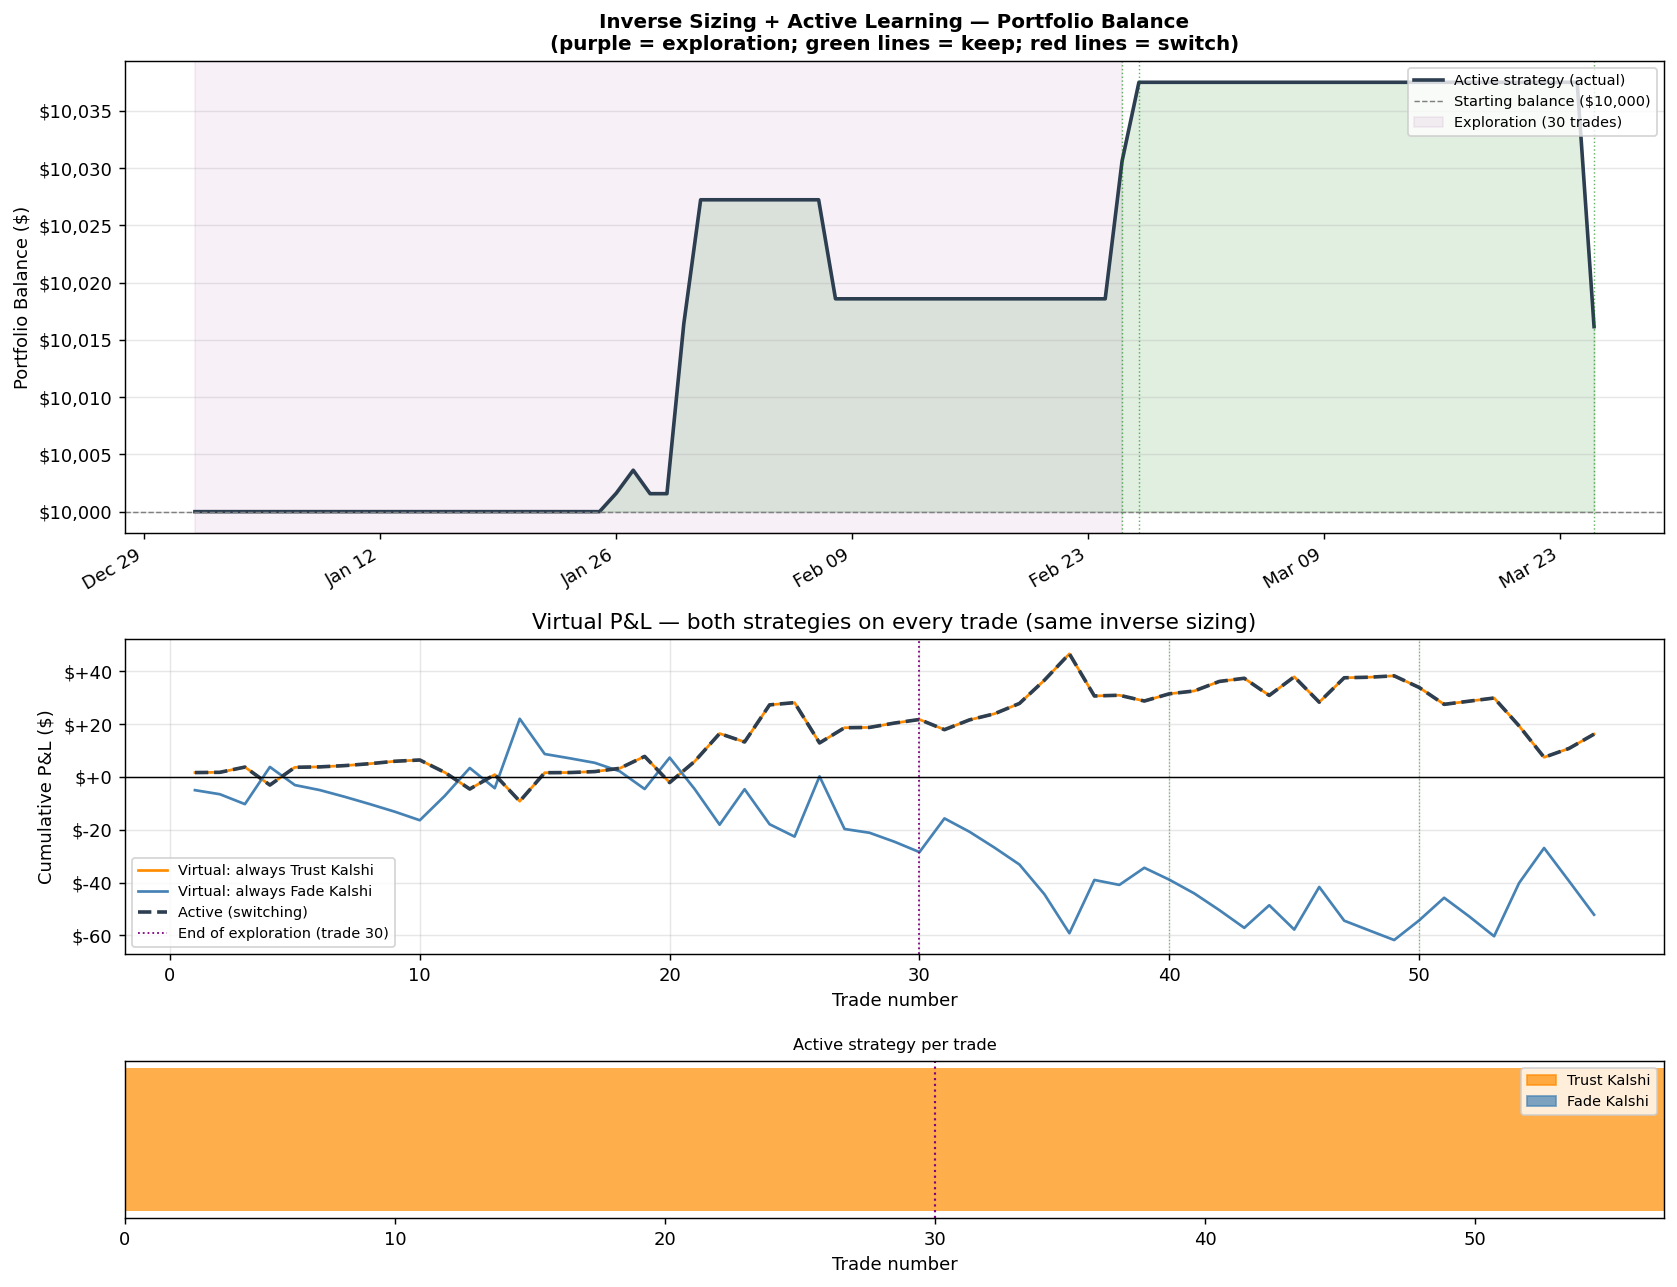

In [9]:
# ── Chart 1: Portfolio + virtual P&L streams + strategy bands ─────────────────
if n_trades == 0:
    print('No trades.')
else:
    df_plot = df.copy()
    df_plot['date_dt'] = pd.to_datetime(df_plot['date'])

    fig, axes = plt.subplots(3, 1, figsize=(13, 10),
                              gridspec_kw={'height_ratios': [3, 2, 1]}, sharex=False)
    ax1, ax2, ax3 = axes

    # Panel 1: Portfolio balance
    ax1.plot(bal_df['date'], bal_df['balance'], color='#2c3e50', linewidth=2,
             label='Active strategy (actual)')
    ax1.axhline(STARTING_BALANCE, color='grey', linewidth=0.8, linestyle='--',
                label=f'Starting balance (${STARTING_BALANCE:,.0f})')
    ax1.fill_between(bal_df['date'], STARTING_BALANCE, bal_df['balance'],
                      where=bal_df['balance'] >= STARTING_BALANCE, alpha=0.12, color='green')
    ax1.fill_between(bal_df['date'], STARTING_BALANCE, bal_df['balance'],
                      where=bal_df['balance'] < STARTING_BALANCE, alpha=0.12, color='red')
    if switch_log:
        expl_end = pd.to_datetime(switch_log[0]['date'])
        ax1.axvspan(bal_df['date'].min(), expl_end,
                    alpha=0.06, color='purple', label=f'Exploration ({INITIAL_RANDOM_TRADES} trades)')
    for ev in switch_log:
        ax1.axvline(pd.to_datetime(ev['date']),
                    color='red' if ev['switched'] else 'green',
                    linewidth=0.8, alpha=0.6, linestyle=':')
    ax1.set_ylabel('Portfolio Balance ($)')
    ax1.set_title('Inverse Sizing + Active Learning — Portfolio Balance\n'
                  '(purple = exploration; green lines = keep; red lines = switch)',
                  fontsize=11, fontweight='bold')
    ax1.legend(loc='upper right', fontsize=8)
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax1.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax1.grid(axis='y', alpha=0.3)

    # Panel 2: Virtual P&Ls
    ax2.plot(df_plot['trade_num'], df_plot['trust_cum'], color='darkorange', linewidth=1.5,
             label='Virtual: always Trust Kalshi')
    ax2.plot(df_plot['trade_num'], df_plot['fade_cum'],  color='steelblue',  linewidth=1.5,
             label='Virtual: always Fade Kalshi')
    ax2.plot(df_plot['trade_num'], df_plot['active_cum'], color='#2c3e50', linewidth=2,
             linestyle='--', label='Active (switching)')
    ax2.axhline(0, color='black', linewidth=0.8)
    ax2.axvline(INITIAL_RANDOM_TRADES, color='purple', linewidth=1, linestyle=':',
                label=f'End of exploration (trade {INITIAL_RANDOM_TRADES})')
    for ev in switch_log[1:]:
        ax2.axvline(ev['trade_num'],
                    color='red' if ev['switched'] else 'green',
                    linewidth=0.7, alpha=0.5, linestyle=':')
    ax2.set_ylabel('Cumulative P&L ($)')
    ax2.set_xlabel('Trade number')
    ax2.set_title('Virtual P&L — both strategies on every trade (same inverse sizing)')
    ax2.legend(loc='lower left', fontsize=8)
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:+,.0f}'))
    ax2.grid(alpha=0.3)

    # Panel 3: Active strategy band
    for i, row in df_plot.iterrows():
        color = 'darkorange' if row['active_strat'] == 'trust' else 'steelblue'
        ax3.barh(0, 1, left=row['trade_num']-1, color=color, height=0.8, alpha=0.7)
    ax3.axvline(INITIAL_RANDOM_TRADES, color='purple', linewidth=1.2, linestyle=':')
    ax3.set_xlim(0, trade_count)
    ax3.set_yticks([])
    ax3.set_xlabel('Trade number')
    ax3.set_title('Active strategy per trade', fontsize=9)
    trust_patch = mpatches.Patch(color='darkorange', alpha=0.7, label='Trust Kalshi')
    fade_patch  = mpatches.Patch(color='steelblue',  alpha=0.7, label='Fade Kalshi')
    ax3.legend(handles=[trust_patch, fade_patch], loc='upper right', fontsize=8)

    plt.tight_layout()
    plt.savefig('inverse_sizing_pnl.png', dpi=130, bbox_inches='tight')
    plt.show()

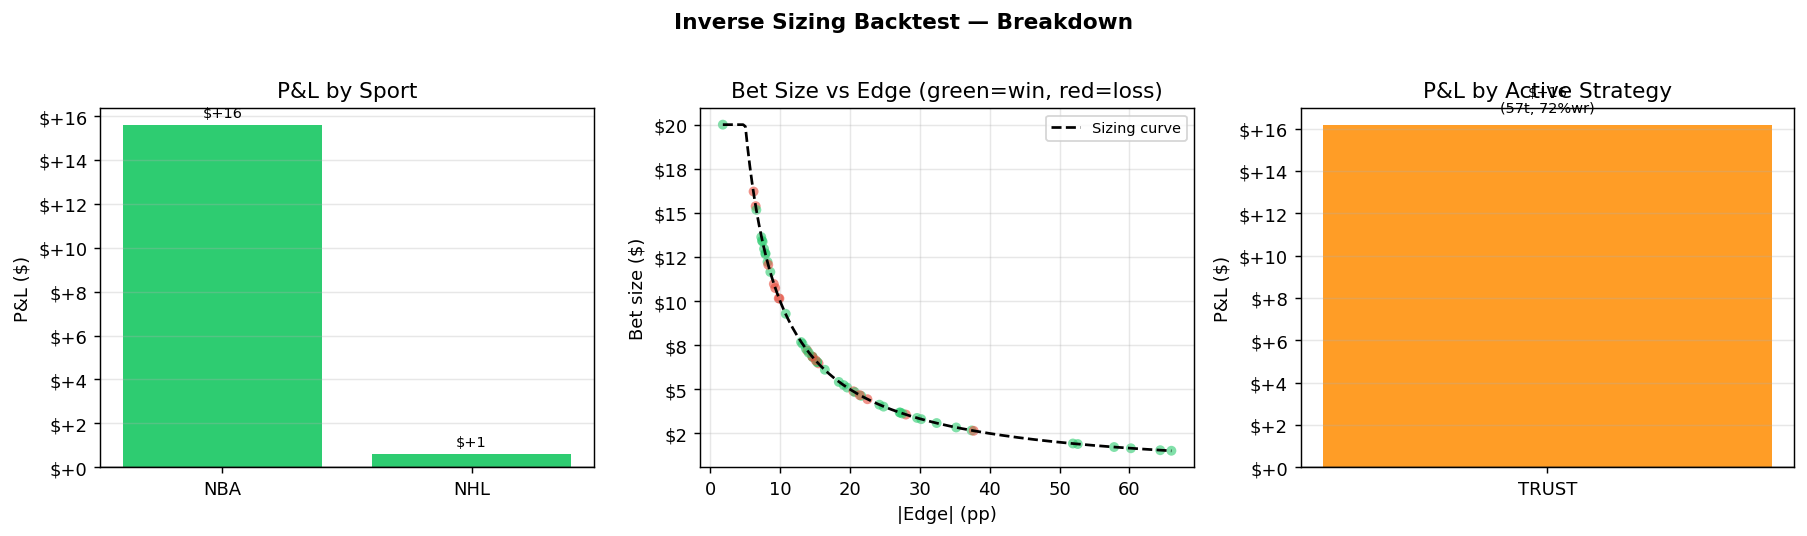

In [10]:
# ── Chart 2: Breakdown ────────────────────────────────────────────────────────
if n_trades == 0:
    print('No trades.')
else:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    # P&L by sport
    ax = axes[0]
    sport_grp = df.groupby('league').agg(
        total_pnl=('pnl','sum'), n_trades=('pnl','count'), win_rate=('won','mean')
    ).sort_values('total_pnl', ascending=False)
    colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in sport_grp['total_pnl']]
    bars = ax.bar(sport_grp.index.str.upper(), sport_grp['total_pnl'], color=colors)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.bar_label(bars, fmt='${:+.0f}', padding=3, fontsize=8)
    ax.set_title('P&L by Sport')
    ax.set_ylabel('P&L ($)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:+,.0f}'))
    ax.grid(axis='y', alpha=0.3)

    # Bet size distribution
    ax = axes[1]
    ax.scatter(df['edge_pp'], df['budget'],
               c=['#2ecc71' if w else '#e74c3c' for w in df['won']],
               alpha=0.6, s=30, edgecolors='none')
    edge_line = np.linspace(df['edge_pp'].min(), df['edge_pp'].max(), 200)
    bet_line  = [bet_size(e) for e in edge_line]
    ax.plot(edge_line, bet_line, color='black', linewidth=1.5, linestyle='--',
            label='Sizing curve')
    ax.set_xlabel('|Edge| (pp)')
    ax.set_ylabel('Bet size ($)')
    ax.set_title('Bet Size vs Edge (green=win, red=loss)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}'))
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # P&L by active strategy
    ax = axes[2]
    strat_grp = df.groupby('active_strat').agg(
        total_pnl=('pnl','sum'), n_trades=('pnl','count'), win_rate=('won','mean')
    )
    strat_colors = {'trust': 'darkorange', 'fade': 'steelblue'}
    bar_colors   = [strat_colors.get(s, 'grey') for s in strat_grp.index]
    bars3 = ax.bar(strat_grp.index.str.upper(), strat_grp['total_pnl'],
                   color=bar_colors, alpha=0.85)
    ax.axhline(0, color='black', linewidth=0.8)
    for bar, (_, row) in zip(bars3, strat_grp.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (0.5 if bar.get_height() >= 0 else -2),
                f'${row["total_pnl"]:+.0f}\n({int(row["n_trades"])}t, {row["win_rate"]*100:.0f}%wr)',
                ha='center', va='bottom', fontsize=8)
    ax.set_title('P&L by Active Strategy')
    ax.set_ylabel('P&L ($)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:+,.0f}'))
    ax.grid(axis='y', alpha=0.3)

    plt.suptitle('Inverse Sizing Backtest — Breakdown', fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('inverse_sizing_breakdown.png', dpi=130, bbox_inches='tight')
    plt.show()

In [11]:
# ── Trade log ─────────────────────────────────────────────────────────────────
if n_trades:
    disp = df[['date','league','title','active_strat','side',
               'kalshi_mid','model_prob','edge_pp','budget',
               'contracts','cost','result','pnl','balance_after']].copy()
    disp.columns = ['Date','League','Market','Strategy','Side',
                    'Kalshi¢','Model%','Edge pp','Bet $',
                    'Contracts','Cost $','Result','P&L $','Balance $']
    pd.set_option('display.max_rows', 120)
    display(disp)

,Date,League,Market,Strategy,Side,Kalshi¢,Model%,Edge pp,Bet $,Contracts,Cost $,Result,P&L $,Balance $
0,2026-01-26,nba,Philadelphia at Charlotte Winner?,trust,no,27.5,47.1,19.6,5.10,6,4.38,no,1.62,10001.62
1,2026-01-27,nba,Sacramento at New York Winner?,trust,no,10.5,74.9,64.4,1.55,1,0.90,no,0.10,10001.72
2,2026-01-27,nhl,Nashville at Boston Winner?,trust,no,33.5,58.3,24.8,4.02,6,4.02,no,1.98,10003.70
3,2026-01-27,nhl,Vegas at Montreal Winner?,trust,yes,67.5,53.6,13.9,7.19,10,6.80,no,-6.80,9996.90
4,2026-01-27,nba,Portland at Washington Winner?,trust,yes,51.5,37.8,13.7,7.29,14,7.28,yes,6.72,10003.62
5,2026-01-28,nhl,New York R at New York I Winner?,trust,no,9.0,60.9,51.9,1.93,2,1.84,no,0.16,10003.78
6,2026-01-28,nhl,Philadelphia at Columbus Winner?,trust,no,16.5,53.9,37.4,2.67,3,2.52,no,0.48,10004.26
7,2026-01-28,nba,Atlanta at Boston Winner?,trust,no,24.5,59.7,35.2,2.84,3,2.28,no,0.72,10004.98
8,2026-01-28,nba,Minnesota at Dallas Winner?,trust,yes,76.5,44.1,32.4,3.09,4,3.08,yes,0.92,10005.90
9,2026-01-28,nba,Los Angeles L at Cleveland Winner?,trust,no,16.5,46.7,30.2,3.31,3,2.52,no,0.48,10006.38
